In [60]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical 

sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from plot_data import *
from process_data import *

In [23]:
file = "data/full_preprocessed_dataframe.parquet"
master_df = pd.read_parquet(file)

In [49]:
# Choose the ones with ABC-SN labels only 
index = ~np.isnan(master_df.ABC_type.values)
df = master_df[index]
df = df.reset_index(drop=True)

# creating y array to use for stratification
y = df["ABC_type"].values
index = df.index.values

In [45]:
train_index, test_index = train_test_split(index, test_size = 0.3, random_state = 7, stratify = y)

In [41]:
data = dp.extract_dataframe(df)

wvl = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
df_metadata = data[5]  # Sub-dataframe containing only the metadata
fluxes0 = data[6]  # Only the flux values in a numpy array

In [62]:
# one hot encode the y values 
y_ohe = to_categorical(y, num_classes=10)

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [70]:
X = fluxes0.copy()
X = X.reshape(X.shape[0],1,X.shape[1])

X_train = X[train_index]
X_test = X[test_index]

y_train = y_ohe[train_index]
y_test = y_ohe[test_index]

In [71]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7807, 1, 139), (3346, 1, 139), (7807, 10), (3346, 10))

## Loading ABC-SN to make predictions


In [105]:
# Loading model 
abcsn = keras.models.load_model("/lustre/lrspec/users/4301/ABC-SN/abcsn/ABCSN.keras", compile=False)

# need manually compile, using the code from ABC-SN/code/abcsn_training 
loss = keras.losses.CategoricalCrossentropy()
acc = keras.metrics.CategoricalAccuracy(name="ca")
f1 = keras.metrics.F1Score(average="macro", name="f1")
lr0_transfer=1e-5
optimizer = keras.optimizers.Nadam(learning_rate=lr0_transfer)
abcsn.compile(loss=loss, optimizer=optimizer, metrics=[acc, f1])

In [106]:
# Fine-tune from this layer onwards
fine_tune_at = len(abcsn.layers)-8

# Freeze all the layers before the `fine_tune_at` layer
for layer in abcsn.layers[:fine_tune_at]:
    layer.trainable = False

In [107]:
abcsn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 139)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 1024)   │    143,360 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 64, 16)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64, 128)   │      2,176 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_position_enco… │ (None, 64, 128)   │          0 │ dense_6[0][0]     │
│ (SinePositionEncod… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64, 64)    │      8,256 │ sine_position_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64, 128)   │      8,320 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 128)   │          0 │ dense_6[0][0],    │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ add_1[0][0]       │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ transformer_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1024)      │  8,389,632 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 1024)      │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    262,400 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 256)       │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,330,058 (35.59 MB)

 Trainable params: 8,669,130 (33.07 MB)

 Non-trainable params: 660,928 (2.52 MB)

In [108]:
len(abcsn.trainable_variables)

8

## Retraining

In [109]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7807, 1, 139), (3346, 1, 139), (7807, 10), (3346, 10))

In [110]:
history = abcsn.fit(X_train, y_train, 
                    validation_data= (X_test, y_test), 
                    epochs = 100,    # choosen arbitrarily 
                    batch_size = 64, # same as willow used
                    verbose= 2
                   )

Epoch 1/100


2026-06-29 14:34:15.959772: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-06-29 14:34:51.698600: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

122/122 - 46s - 377ms/step - ca: 0.4372 - f1: 0.0872 - loss: 5.3066 - val_ca: 0.6473 - val_f1: 0.1064 - val_loss: 3.9593
Epoch 2/100
122/122 - 40s - 329ms/step - ca: 0.6590 - f1: 0.1076 - loss: 3.8897 - val_ca: 0.7253 - val_f1: 0.1085 - val_loss: 3.5680
Epoch 3/100
122/122 - 41s - 333ms/step - ca: 0.6976 - f1: 0.1153 - loss: 3.6957 - val_ca: 0.7543 - val_f1: 0.1259 - val_loss: 3.4384
Epoch 4/100
122/122 - 40s - 330ms/step - ca: 0.7178 - f1: 0.1205 - loss: 3.5835 - val_ca: 0.7660 - val_f1: 0.1344 - val_loss: 3.3511
Epoch 5/100
122/122 - 40s - 331ms/step - ca: 0.7286 - f1: 0.1256 - loss: 3.5000 - val_ca: 0.7759 - val_f1: 0.1410 - val_loss: 3.2798
Epoch 6/100
122/122 - 40s - 331ms/step - ca: 0.7405 - f1: 0.1294 - loss: 3.4206 - val_ca: 0.7809 - val_f1: 0.1440 - val_loss: 3.2199
Epoch 7/100
122/122 - 41s - 334ms/step - ca: 0.7480 - f1: 0.1345 - loss: 3.3442 - val_ca: 0.7839 - val_f1: 0.1458 - val_loss: 3.1620
Epoch 8/100
122/122 - 41s - 334ms/step - ca: 0.7512 - f1: 0.1358 - loss: 3.2870 -

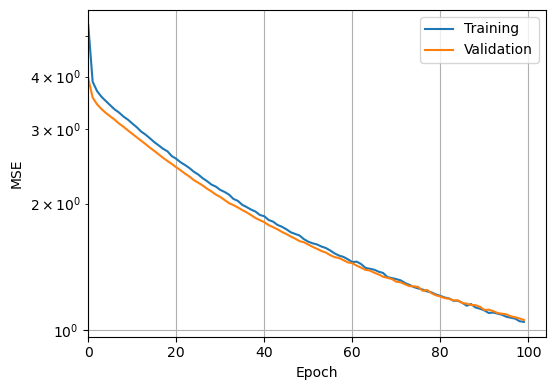

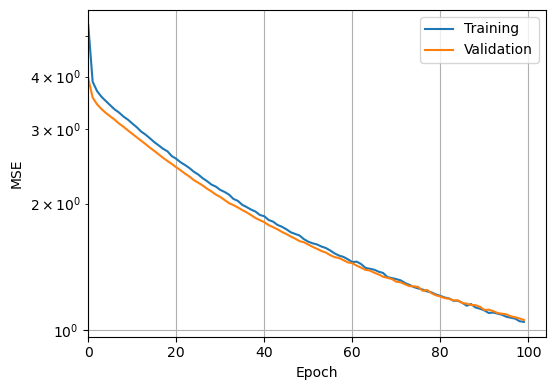

In [111]:
log = history.history
abcsn_training.plot_loss(log, scale=4, cb_es=None, patience_es=None)

## Results

In [129]:

df_test = df.iloc[test_index].copy()

# predict type
P = abcsn.predict(X_test, verbose=0)
P_argmax = np.argmax(P, axis=1)

df_test["Pred_ABC_ID"] = P_argmax

# get type as milligan ID
ABC_to_Mill = get_ABC_to_Mill_dict()
P_Mill = np.array([ABC_to_Mill[i] for i in P_argmax])
df_test["Pred_Mill_ID"] = P_Mill


2026-06-29 16:00:10.665471: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


### Checking various types

In [130]:
# Looking at milligan id counts
np.unique(P_argmax, return_counts=True)

(array([0, 4, 6, 9]), array([2586,    7,   70,  683]))

In [133]:
np.unique(P_Mill, return_counts=True)

(array([0, 1, 2]), array([2586,   77,  683]))

# Looking at the results of prediction with ABCSN labels

In [135]:
Y_ABC_IDs = df_test.ABC_type.values

cr = (classification_report(
    Y_ABC_IDs,
    P_argmax,
    labels=list(ABC_subtype_id_to_str.keys()),
    target_names=list(ABC_subtype_id_to_str.values())
    ))

print(cr)
#may be skewed 

              precision    recall  f1-score   support

     Ia-norm       0.90      0.96      0.93      2422
      Ia-91T       0.00      0.00      0.00        79
     Ia-91bg       0.00      0.00      0.00         0
         Iax       0.00      0.00      0.00         0
     Ib-norm       0.43      0.04      0.07        78
         Ibn       0.00      0.00      0.00         0
         IIb       0.77      0.33      0.46       163
     Ic-norm       0.00      0.00      0.00        58
    Ic-broad       0.00      0.00      0.00         0
         IIP       0.74      0.92      0.82       546

    accuracy                           0.87      3346
   macro avg       0.28      0.23      0.23      3346
weighted avg       0.82      0.87      0.83      3346



/home/4301/miniconda3/envs/abcsn/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/4301/miniconda3/envs/abcsn/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/4301/miniconda3/envs/abcsn/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

In [9]:
np.unique(Y_ABC_IDs, return_counts=True)
# what changed between the 9s and nans 

(array([ 0.,  1.,  4.,  6.,  7.,  9., nan]),
 array([8074,  263,  262,  542,  193, 1819, 2290]))

In [136]:
ABC_ID_dict = get_ABC_ID_dict()

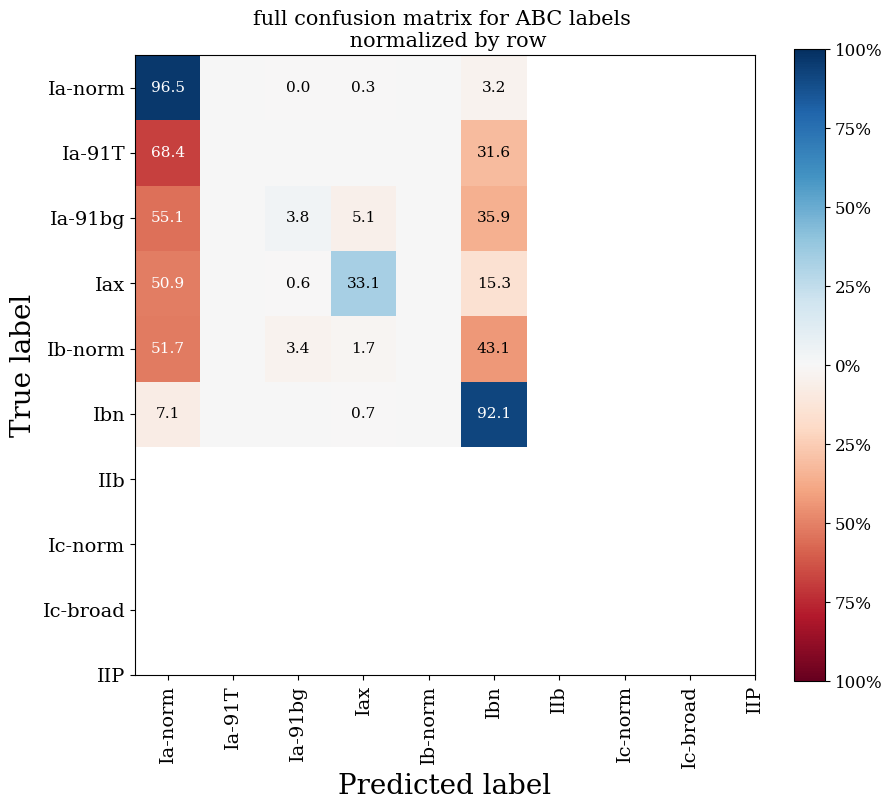

In [139]:
ABC_ID_dict = get_ABC_ID_dict()

cm = confusion_matrix(df_test.ABC_type.values, 
                      df_test.Pred_ABC_ID.values)
plot = plot_cm(cm, list(ABC_ID_dict.values()), 
               title = "full confusion matrix for ABC labels \n normalized by row",
              normalize = True)

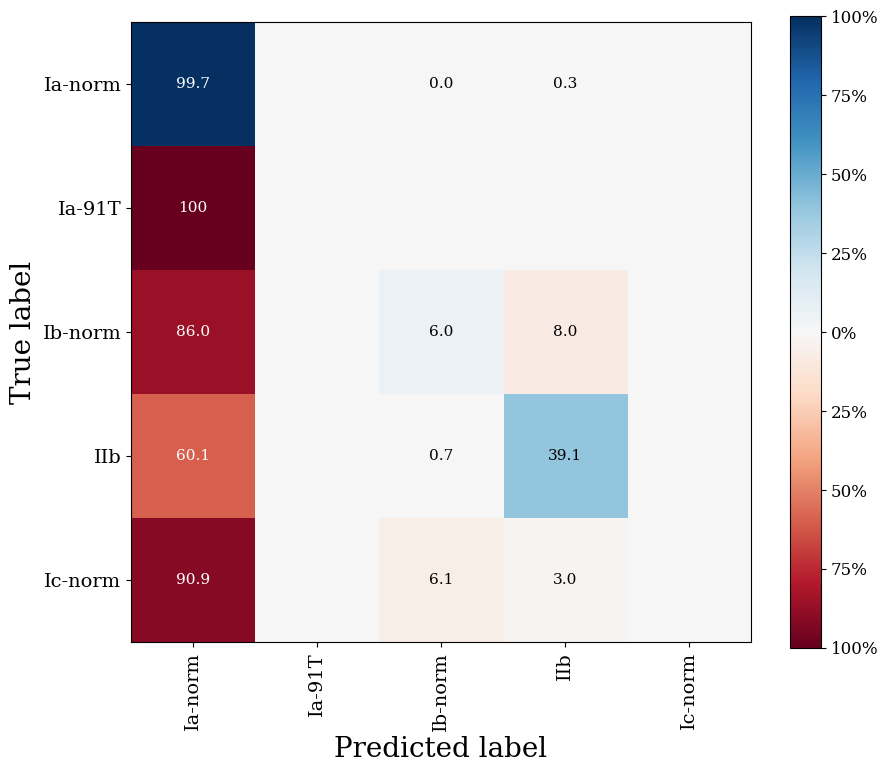

In [140]:
# truncated confusion matrix for ABC labels
truncated_labels = [ABC_ID_dict[id] for id in np.unique(Y_ABC_IDs)[:-1]]
## note last one is removed because it is nan

cm = confusion_matrix(df_test.ABC_type.values, df_test.Pred_ABC_ID.values, 
                           labels=np.unique(Y_ABC_IDs)[:-1])
plot = plot_cm(cm, truncated_labels)

## look at various normalizations

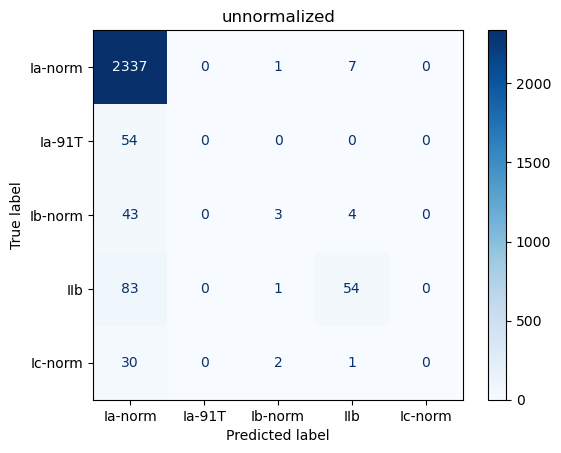

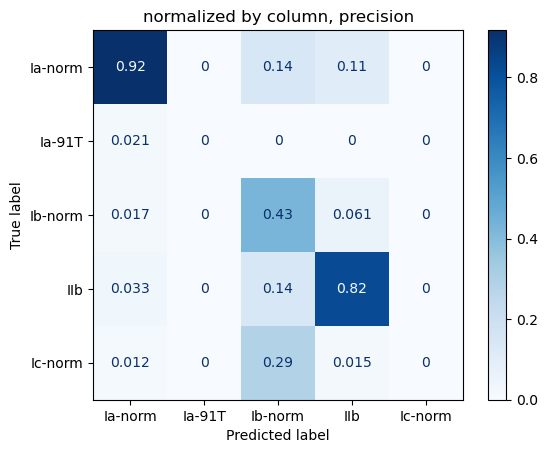

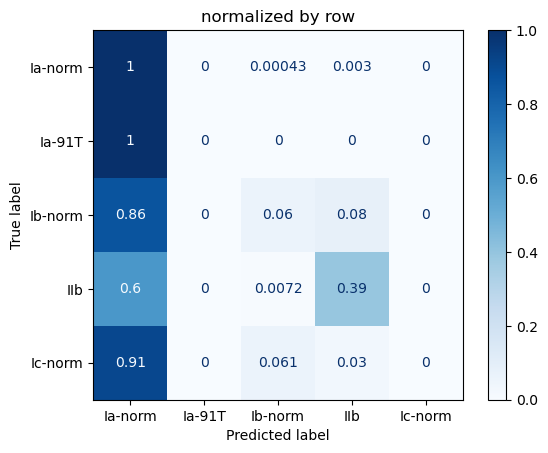

In [141]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(df_test.ABC_type.values, 
                          df_test.Pred_ABC_ID.values, 
                          labels=np.unique(Y_ABC_IDs)[:-1],
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=truncated_labels)
    disp.plot(cmap='Blues')
    plt.title(titles[i])
    plt.show()

## Looking at close and bright SN objects

In [143]:

brighter_SN_index = df_test.host_mag > df_test.SN_mag + 1
small_z_index = df_test.redshift < 0.05
print(sum(small_z_index & brighter_SN_index))
bright_close_index = small_z_index & brighter_SN_index

bright_close_SN_df = df_test[bright_close_index].copy()

41


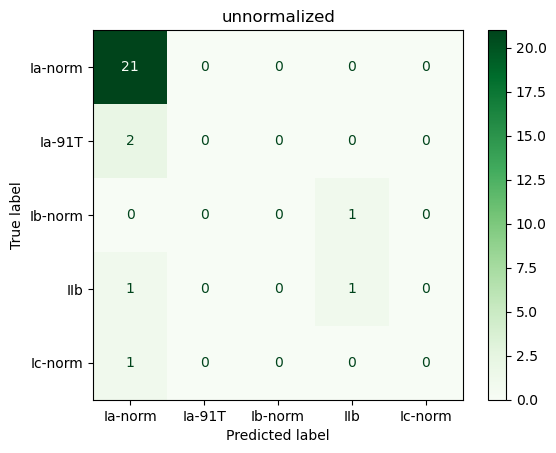

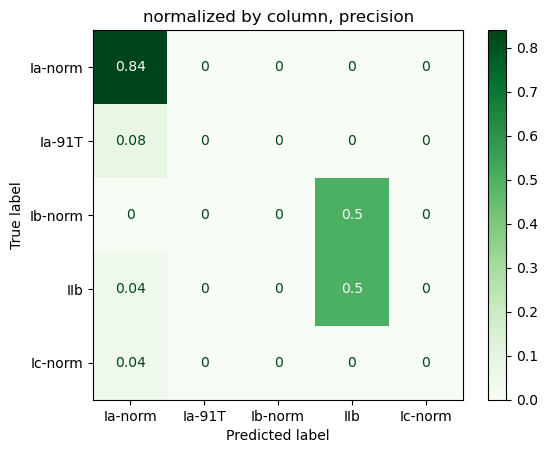

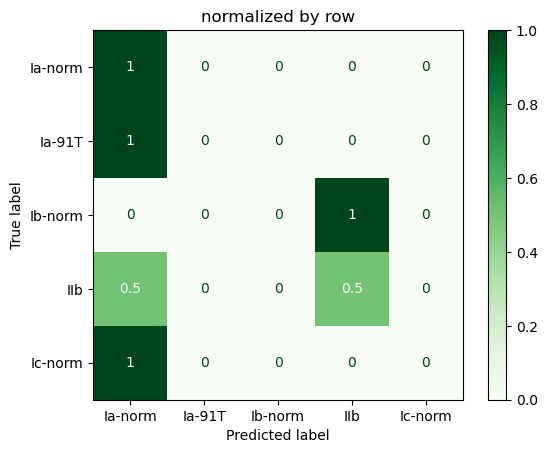

In [144]:
normalizations = [None, "pred", "true"]
titles = ["unnormalized", "normalized by column, precision", "normalized by row"]

for i in range(3):
    cm = confusion_matrix(bright_close_SN_df.ABC_type.values, 
                          bright_close_SN_df.Pred_ABC_ID.values, 
                          labels=np.unique(Y_ABC_IDs)[:-1],
                          normalize=normalizations[i])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=truncated_labels)
    disp.plot(cmap='Greens')
    plt.title(titles[i])
    plt.show()

## Using Milligan Labels

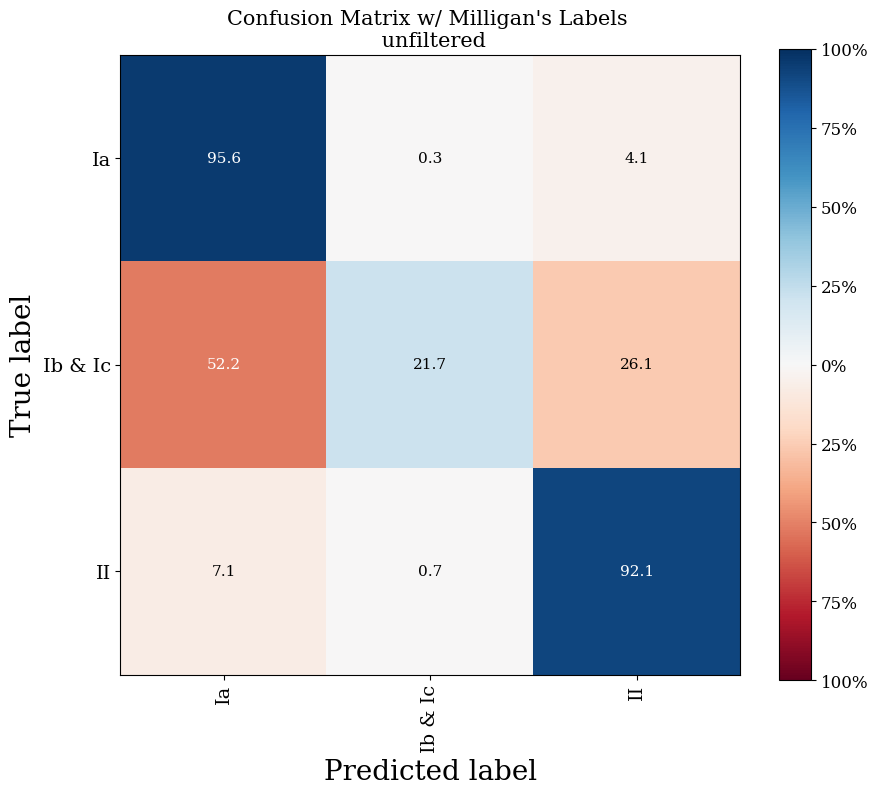

In [145]:

cm_mill = confusion_matrix(df_test.Mill_type, df_test.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n unfiltered")

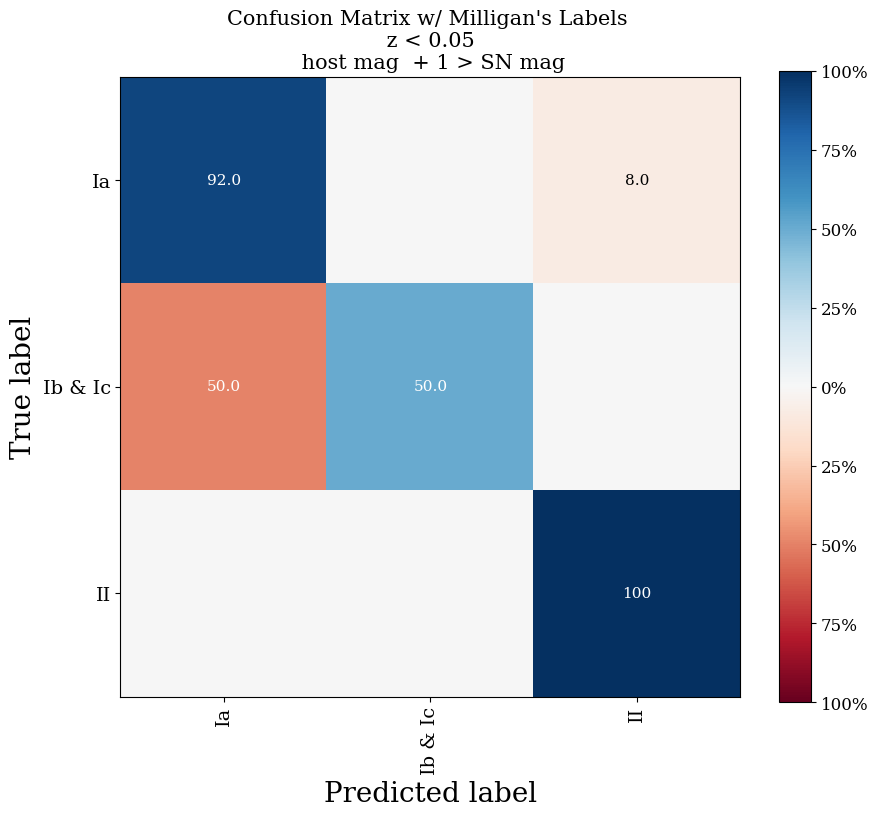

In [146]:
cm_mill = confusion_matrix(bright_close_SN_df.Mill_type, bright_close_SN_df.Pred_Mill_ID, 
                           labels=list(Mill_types_to_int.keys()))
plot = plot_cm(cm_mill[:3, :3], list(Mill_types_to_int.values())[:3], 
        title = "Confusion Matrix w/ Milligan's Labels \n z < 0.05 \n host mag  + 1 > SN mag")

# Looking at classification spectra ... not particulary useful

/tmp/ipykernel_10862/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_10862/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_10862/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_10862/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_10862/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
/tmp/ipykernel_10862/3647232966.py:26: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")


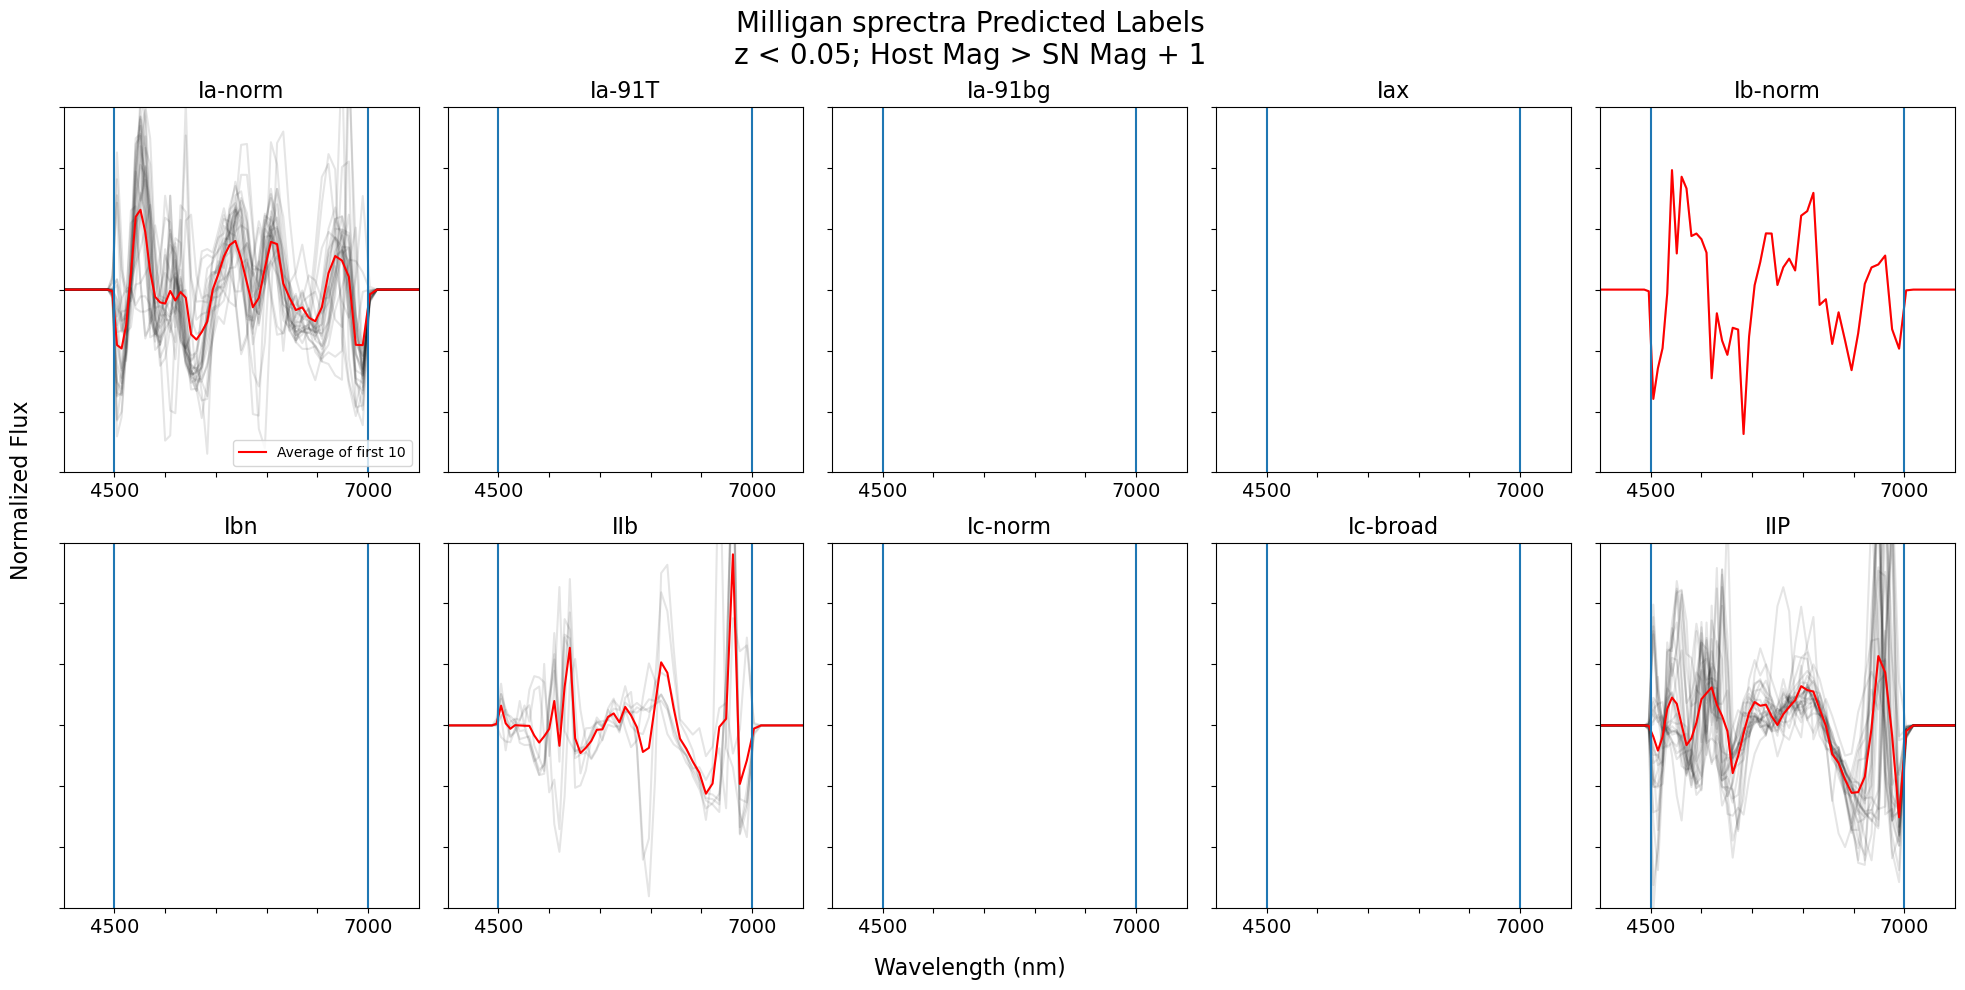

In [148]:
types = list(ABC_subtype_id_to_str.keys())
types_titles = list(ABC_subtype_id_to_str.values())
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = df_test.host_mag > df_test.SN_mag +1
small_z_index = df_test.redshift < 0.05
close_bright_df = df_test[small_z_index] #df[brighter_SN_index & small_z_index]
num_wvl = 139
flux_start, flux_stop = 59, 103


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = close_bright_df[close_bright_df.Pred_ABC_ID == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += fluxes0[i]
        if n < 25:
            ax.plot(wvl, fluxes0[i], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticks([-3,-2,-1, 0, 1,2,3])
    ax.set_yticklabels(["", "", " ", " ", "", "", "" ])
    if j == 0:
        ax.legend()
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

    ax.axvline(4500)
    ax.axvline(7000)

fig.suptitle("Milligan sprectra Predicted Labels\nz < 0.05; Host Mag > SN Mag + 1", fontsize =20)

fig.supxlabel("Wavelength (nm)", fontsize = 16)
fig.supylabel("Normalized Flux\n", fontsize = 16)


plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
